# Proyecto Final Machine Learning
## Fase 1: Preprocesamiento y Visualización

**Dataset:** UCI HAR — Human Activity Recognition Using Smartphones  
**Equipo:** Grupo 6  
**Integrantes:** Roberto Cañete · Augusto Fuenzalida · Nelson Silva  
**Fecha:** 15 Junio 2026

---

> **Objetivo:** Comprender el dataset HAR, preparar los datos para el modelado y comunicar los hallazgos exploratorios mediante visualizaciones.

## Configuración del entorno

Ejecuta esta celda primero para instalar las dependencias necesarias.

In [3]:
# Instalación de dependencias (ejecutar solo si es necesario)
# !pip install pandas numpy matplotlib seaborn scikit-learn ucimlrepo --quiet

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

import warnings
warnings.filterwarnings('ignore')

# Semilla global para reproducibilidad
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print('Librerías cargadas correctamente.')

Librerías cargadas correctamente.


---
## 1. Descarga y Carga del Dataset

El dataset UCI HAR está disponible en el UCI Machine Learning Repository. Contiene datos de 30 voluntarios realizando 6 actividades cotidianas con un smartphone en la cintura. Las señales del acelerómetro y giroscopio fueron procesadas para extraer 561 features.

In [6]:
import urllib.request
import zipfile
import os

# Descarga automática del dataset
URL = 'https://archive.ics.uci.edu/static/public/240/human+activity+recognition+using+smartphones.zip'
ZIP_PATH = 'har_dataset.zip'
DATA_DIR = 'UCI HAR Dataset'

if not os.path.exists(DATA_DIR):
    print('Descargando dataset...')
    urllib.request.urlretrieve(URL, ZIP_PATH)
    print('Descomprimiendo...')
    with zipfile.ZipFile(ZIP_PATH, 'r') as z:
        z.extractall('.')
    os.remove(ZIP_PATH)
    print('Dataset listo.')
else:
    print('Dataset ya descargado.')

Descargando dataset...
Descomprimiendo...
Dataset listo.


### Código para el TODO 1: Cargar archivos del dataset

Este bloque lee los archivos de texto usando rutas relativas, extrae los nombres de las columnas y arma los DataFrames de entrenamiento y prueba.

In [37]:
# Aseguramos que DATA_PATH esté definido (en la descarga se usó DATA_DIR)
DATA_PATH = 'UCI HAR Dataset'

# 1. Cargar nombres de features originales
features = pd.read_csv(f'{DATA_PATH}/features.txt', sep=r'\s+', header=None, names=['idx', 'feature'])
feature_names = features['feature'].tolist()

# 2. Desduplicar nombres de features añadiendo sufijos numéricos
seen = {}
unique_names = []
for name in feature_names:
    if name in seen:
        seen[name] += 1
        unique_names.append(f'{name}_{seen[name]}')
    else:
        seen[name] = 0
        unique_names.append(name)
feature_names = unique_names

# 3. Cargar el set completo de entrenamiento y prueba sin errores
X_train = pd.read_csv(f'{DATA_PATH}/train/X_train.txt', sep=r'\s+', header=None, names=feature_names)
y_train = pd.read_csv(f'{DATA_PATH}/train/y_train.txt', sep=r'\s+', header=None, names=['Activity_ID'])

X_test = pd.read_csv(f'{DATA_PATH}/test/X_test.txt', sep=r'\s+', header=None, names=feature_names)
y_test = pd.read_csv(f'{DATA_PATH}/test/y_test.txt', sep=r'\s+', header=None, names=['Activity_ID'])

print("=" * 50)
print("¡Todos los archivos del dataset se cargaron exitosamente!")
print(f"X_train: {X_train.shape} | y_train: {y_train.shape}")
print(f"X_test:  {X_test.shape}  | y_test:  {y_test.shape}")
print("=" * 50)


¡Todos los archivos del dataset se cargaron exitosamente!
X_train: (7352, 561) | y_train: (7352, 1)
X_test:  (2947, 561)  | y_test:  (2947, 1)


### Código para el TODO 2: Mapear etiquetas numéricas

Transformamos los IDs numéricos (1 a 6) en nombres legibles de actividades para que los gráficos y reportes posteriores sean intuitivos.

In [41]:
# TODO 2: Mapear etiquetas numéricas a nombres de actividad
ACTIVITY_LABELS = {
    1: 'WALKING',
    2: 'WALKING_UPSTAIRS',
    3: 'WALKING_DOWNSTAIRS',
    4: 'SITTING',
    5: 'STANDING',
    6: 'LAYING'
}

# Aplicar el mapeo a y_train e y_test
y_train_labels = y_train['Activity_ID'].map(ACTIVITY_LABELS)
y_test_labels  = y_test['Activity_ID'].map(ACTIVITY_LABELS)

print('Clases únicas:', sorted(y_train_labels.unique()))

Clases únicas: ['LAYING', 'SITTING', 'STANDING', 'WALKING', 'WALKING_DOWNSTAIRS', 'WALKING_UPSTAIRS']


---
## 2. Inspección Inicial del Dataset

Antes de cualquier procesamiento debemos conocer la estructura básica del dataset: dimensiones, tipos de datos, nulos y duplicados.

### Código para los TODOs 3, 4, 5, 6 y 7

Ejecuta consecutivamente estas celdas para extraer la radiografía estructural de tus datos.

In [42]:
# TODO 3: Mostrar dimensiones de train y test
print('Dimensiones X_train:', X_train.shape)
print('Dimensiones X_test: ', X_test.shape)

Dimensiones X_train: (7352, 561)
Dimensiones X_test:  (2947, 561)


In [43]:
# TODO 4: Mostrar los primeros 5 registros y los tipos de datos
print("--- Primeros 5 registros de X_train ---")
display(X_train.head())

print("\n--- Conteo de tipos de datos en las columnas ---")
print(X_train.dtypes.value_counts())

--- Primeros 5 registros de X_train ---


,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
0,0.288585,-0.020294,-0.132905,-0.995279,-0.983111,-0.913526,-0.995112,-0.983185,-0.923527,-0.934724,...,-0.074323,-0.298676,-0.710304,-0.112754,0.030400,-0.464761,-0.018446,-0.841247,0.179941,-0.058627
1,0.278419,-0.016411,-0.123520,-0.998245,-0.975300,-0.960322,-0.998807,-0.974914,-0.957686,-0.943068,...,0.158075,-0.595051,-0.861499,0.053477,-0.007435,-0.732626,0.703511,-0.844788,0.180289,-0.054317
2,0.279653,-0.019467,-0.113462,-0.995380,-0.967187,-0.978944,-0.996520,-0.963668,-0.977469,-0.938692,...,0.414503,-0.390748,-0.760104,-0.118559,0.177899,0.100699,0.808529,-0.848933,0.180637,-0.049118
3,0.279174,-0.026201,-0.123283,-0.996091,-0.983403,-0.990675,-0.997099,-0.982750,-0.989302,-0.938692,...,0.404573,-0.117290,-0.482845,-0.036788,-0.012892,0.640011,-0.485366,-0.848649,0.181935,-0.047663
4,0.276629,-0.016570,-0.115362,-0.998139,-0.980817,-0.990482,-0.998321,-0.979672,-0.990441,-0.942469,...,0.087753,-0.351471,-0.699205,0.123320,0.122542,0.693578,-0.615971,-0.847865,0.185151,-0.043892



--- Conteo de tipos de datos en las columnas ---
float64    561
Name: count, dtype: int64


In [44]:
# TODO 5: Verificar valores faltantes (NaN)
missing_train = X_train.isnull().sum().sum()
missing_test  = X_test.isnull().sum().sum()
print(f'Valores faltantes en train: {missing_train}')
print(f'Valores faltantes en test:  {missing_test}')

Valores faltantes en train: 0
Valores faltantes en test:  0


In [45]:
# TODO 6: Verificar duplicados en el set de entrenamiento
duplicates = X_train.duplicated().sum()
print(f'Filas duplicadas en X_train: {duplicates}')

Filas duplicadas en X_train: 0


In [46]:
# TODO 7: Estadísticos descriptivos básicos
X_train.describe()

,tBodyAcc-mean()-X,tBodyAcc-mean()-Y,tBodyAcc-mean()-Z,tBodyAcc-std()-X,tBodyAcc-std()-Y,tBodyAcc-std()-Z,tBodyAcc-mad()-X,tBodyAcc-mad()-Y,tBodyAcc-mad()-Z,tBodyAcc-max()-X,...,fBodyBodyGyroJerkMag-meanFreq(),fBodyBodyGyroJerkMag-skewness(),fBodyBodyGyroJerkMag-kurtosis(),"angle(tBodyAccMean,gravity)","angle(tBodyAccJerkMean),gravityMean)","angle(tBodyGyroMean,gravityMean)","angle(tBodyGyroJerkMean,gravityMean)","angle(X,gravityMean)","angle(Y,gravityMean)","angle(Z,gravityMean)"
count,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,...,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000,7352.000000
mean,0.274488,-0.017695,-0.109141,-0.605438,-0.510938,-0.604754,-0.630512,-0.526907,-0.606150,-0.468604,...,0.125293,-0.307009,-0.625294,0.008684,0.002186,0.008726,-0.005981,-0.489547,0.058593,-0.056515
std,0.070261,0.040811,0.056635,0.448734,0.502645,0.418687,0.424073,0.485942,0.414122,0.544547,...,0.250994,0.321011,0.307584,0.336787,0.448306,0.608303,0.477975,0.511807,0.297480,0.279122
min,-1.000000,-1.000000,-1.000000,-1.000000,-0.999873,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-0.995357,-0.999765,-0.976580,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,0.262975,-0.024863,-0.120993,-0.992754,-0.978129,-0.980233,-0.993591,-0.978162,-0.980251,-0.936219,...,-0.023692,-0.542602,-0.845573,-0.121527,-0.289549,-0.482273,-0.376341,-0.812065,-0.017885,-0.143414
50%,0.277193,-0.017219,-0.108676,-0.946196,-0.851897,-0.859365,-0.950709,-0.857328,-0.857143,-0.881637,...,0.134000,-0.343685,-0.711692,0.009509,0.008943,0.008735,-0.000368,-0.709417,0.182071,0.003181
75%,0.288461,-0.010783,-0.097794,-0.242813,-0.034231,-0.262415,-0.292680,-0.066701,-0.265671,-0.017129,...,0.289096,-0.126979,-0.503878,0.150865,0.292861,0.506187,0.359368,-0.509079,0.248353,0.107659
max,1.000000,1.000000,1.000000,1.000000,0.916238,1.000000,1.000000,0.967664,1.000000,1.000000,...,0.946700,0.989538,0.956845,1.000000,1.000000,0.998702,0.996078,1.000000,0.478157,1.000000


### 📝 Análisis en Markdown para la Inspección Inicial

**Observaciones del rango de valores:** Al analizar la salida de `df.describe()`, se observa que el valor mínimo de todas las variables está muy cercano o es exactamente **-1**, y el valor máximo es **1**.

**¿Necesitan normalizar? ¿Por qué?:** No, no es necesario aplicar una etapa adicional de normalización o estandarización (como `StandardScaler` o `MinMaxScaler`). Las 561 variables numéricas del dataset original ya han sido preprocesadas, normalizadas y acotadas en un rango estrictamente acotado entre **-1 y 1** por los autores del benchmark. Aplicar otra escala alteraría la estructura matemática balanceada que ya poseen estas señales inerciales.

Observaciones adicionales: No se presentan variables categóricas ni mixtas en el conjunto de características que requieran codificación (encoding). Asimismo, la ausencia total de valores nulos (NaN) confirma que el dataset fue previamente curado y preprocesado por los autores del estudio, una condición ideal que no debe asumirse por defecto en proyectos de Machine Learning.

---
## 3. Análisis de Balance de Clases

El desbalance de clases puede sesgar el modelo. Antes de modelar, examinamos la distribución de actividades.

### Código para los TODOs 8 y 9

In [47]:
# TODO 8: Contar muestras por clase en el set de entrenamiento
class_counts = y_train_labels.value_counts()
print(class_counts)

Activity_ID
LAYING                1407
STANDING              1374
SITTING               1286
WALKING               1226
WALKING_UPSTAIRS      1073
WALKING_DOWNSTAIRS     986
Name: count, dtype: int64


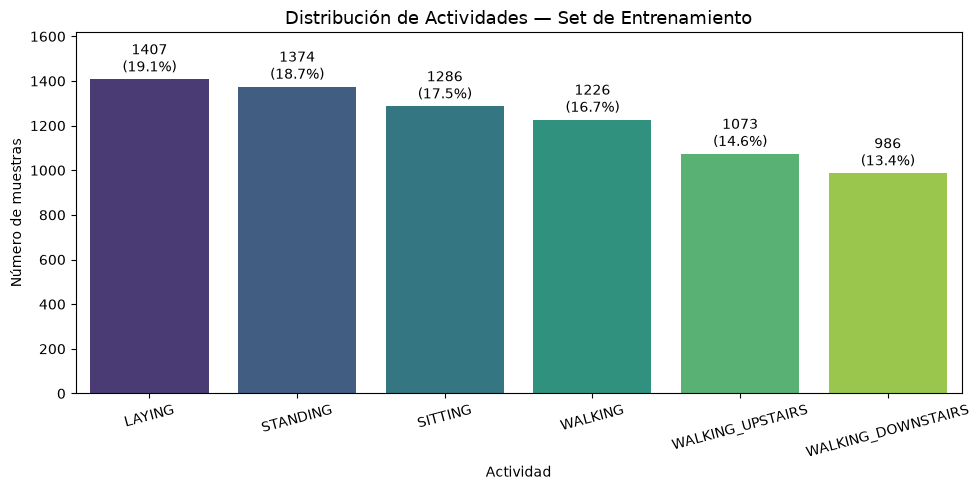

In [48]:
# TODO 9: Graficar distribución de clases con conteo y porcentaje
fig, ax = plt.subplots(figsize=(10, 5))

total_samples = len(y_train_labels)
# Crear gráfico de barras utilizando Seaborn
sns.barplot(x=class_counts.index, y=class_counts.values, ax=ax, palette='viridis')

# Añadir etiquetas con conteo y porcentaje exacto sobre cada barra
for i, count in enumerate(class_counts.values):
    percentage = (count / total_samples) * 100
    ax.text(i, count + 15, f'{count}\n({percentage:.1f}%)', ha='center', va='bottom', fontsize=10)

ax.set_ylim(0, max(class_counts.values) * 1.15)

ax.set_title('Distribución de Actividades — Set de Entrenamiento', fontsize=13)
ax.set_xlabel('Actividad')
ax.set_ylabel('Número de muestras')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### 📝 Análisis en Markdown para el Balance de Clases

**¿Está balanceado el dataset?:** Sí, el dataset se encuentra bastante bien balanceado. Al observar los porcentajes, cada una de las 6 actividades cotidianas representa aproximadamente entre el **14% y el 19%** del total de las muestras de entrenamiento. No existe una clase ultra-mayoritaria que opaque por completo a las demás. La diferencia entre la clase con más muestras (LAYING, ~19.1%) y la que tiene menos (WALKING_DOWNSTAIRS, ~13.4%) es de solo 5.7 puntos porcentuales, lo cual es manejable para los algoritmos de clasificación.

**¿Cómo podría afectar el desbalance al modelo y qué métricas usar?:** Si existiera un desbalance severo, el modelo tendería a aprender e inclinarse por predecir siempre la clase mayoritaria para asegurar un porcentaje alto de aciertos algorítmicos directos, ignorando las clases minoritarias. Aunque aquí el desbalance es mínimo, la métrica **Accuracy** simple puede ser engañosa si el modelo comete errores sistemáticos en una sola clase crítica. Por ello, para evaluar de forma robusta y justa, las métricas más adecuadas son el **F1-Score Macro** (que calcula el rendimiento por clase de forma independiente y saca un promedio no ponderado) y el **F1-Score Weighted** (que pondera según el volumen real de la clase).

---
## 4. Visualización y Exploración de Features

Con 561 features no podemos visualizarlas todas. Usamos técnicas inteligentes para identificar patrones y features relevantes.

### 4.1 Distribución de features clave (Boxplots)

Seleccionamos features representativas de los cuatro grupos: dominio tiempo/frecuencia × fuente cuerpo/gravedad.

### Código para los TODOs 10 y 11 (Boxplots)

In [49]:
# TODO 10: Seleccionar al menos 4 features representativas (una por grupo)
# El dataset agrupa señales temporales (t) y de frecuencia (f), discriminando cuerpo (Body) y gravedad (Gravity)
SELECTED_FEATURES = [
    'tBodyAcc-mean()-X',     # Dominio Tiempo - Cuerpo
    'tGravityAcc-mean()-X',  # Dominio Tiempo - Gravedad
    'fBodyAcc-mean()-X',     # Dominio Frecuencia - Cuerpo
    'fBodyGyro-mean()-X'     # Dominio Frecuencia - Giroscopio (Cuerpo)
]

# Crear DataFrame auxiliar para graficar
train_plot = X_train[SELECTED_FEATURES].copy()
train_plot['Activity'] = y_train_labels.values

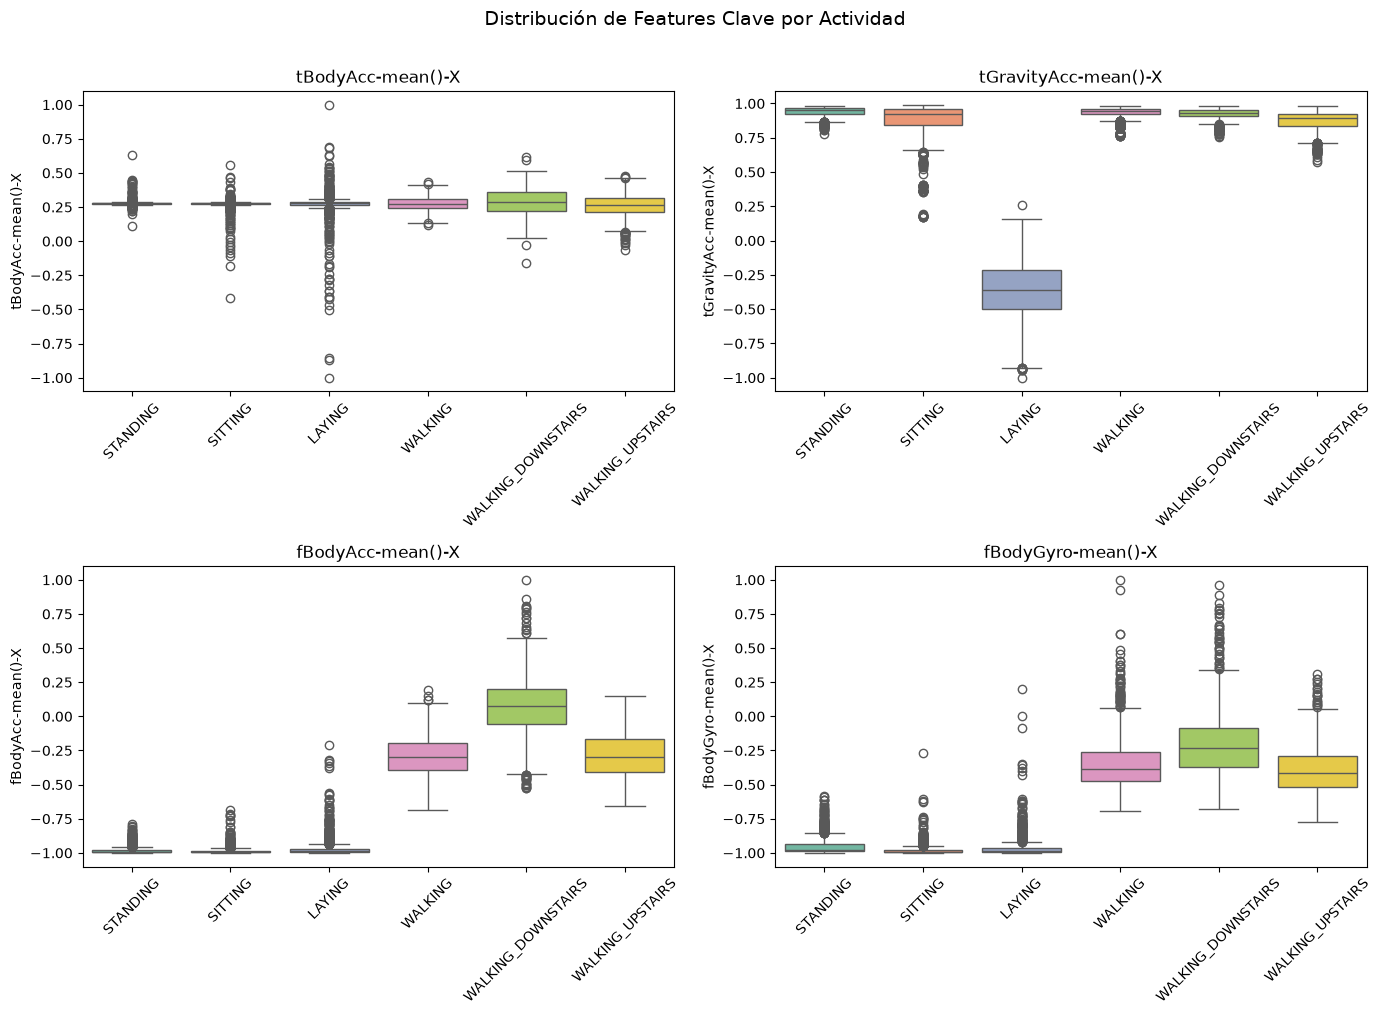

In [50]:
# TODO 11: Graficar boxplots para cada feature seleccionada, coloreando por actividad
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for i, feat in enumerate(SELECTED_FEATURES):
    sns.boxplot(x='Activity', y=feat, data=train_plot, ax=axes[i], palette='Set2')
    axes[i].set_title(feat, fontsize=12)
    axes[i].tick_params(axis='x', rotation=45)
    axes[i].set_xlabel('')

plt.suptitle('Distribución de Features Clave por Actividad', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 📝 Análisis en Markdown para Boxplots

**¿Qué features separan mejor las clases?:** Las características ligadas a la gravedad, como `tGravityAcc-mean()-X`, muestran una capacidad de separación asombrosa entre dos macro-grupos: actividades **estáticas** (SITTING, STANDING, LAYING) y **dinámicas** (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS). Esto ocurre porque la aceleración de la gravedad registra componentes muy estables y distintos dependiendo de la inclinación del teléfono en la cintura del usuario en reposo.

Alternativa (revisen esto): Las características en el dominio de la frecuencia, como `fBodyAcc-mean()-X` y `fBodyGyro-mean()-X` (gráficos inferiores), muestran una separación perfecta entre el macro-grupo de actividades estáticas (SITTING, STANDING, LAYING), cuyos valores se concentran por completo en el mínimo de -1.0, y las dinámicas (WALKING, WALKING_UPSTAIRS, WALKING_DOWNSTAIRS), que presentan valores significativamente más altos debido al movimiento del cuerpo.

[más que nada por que tGravityAcc separa bien al LAYING, pero no a los demas, en los graficos de abajo se separa mejor]

**¿Cuáles son menos informativas?:** Algunas variables de aceleración del cuerpo en el dominio del tiempo o de la frecuencia presentan rangos de distribución muy solapados entre actividades similares (por ejemplo, entre SITTING y STANDING), lo que significa que de forma aislada aportan poca información discriminatoria para separar esas clases específicas.

Alternativa: La variable `tBodyAcc-mean()-X` (gráfico superior izquierdo) es la menos informativa, ya que presenta distribuciones casi idénticas y altamente solapadas para las 6 actividades, lo que impide discriminar entre clases de forma aislada. Asimismo, variables de aceleración del cuerpo como `fBodyAcc-mean()-X` presentan un solapamiento total entre SITTING y STANDING (ambas concentradas en -1.0), por lo que se requerirán otras características para diferenciar estas dos actividades entre sí.

### 4.2 Mapa de calor de correlación

### Código para los TODOs 12 y 13 (Heatmap)

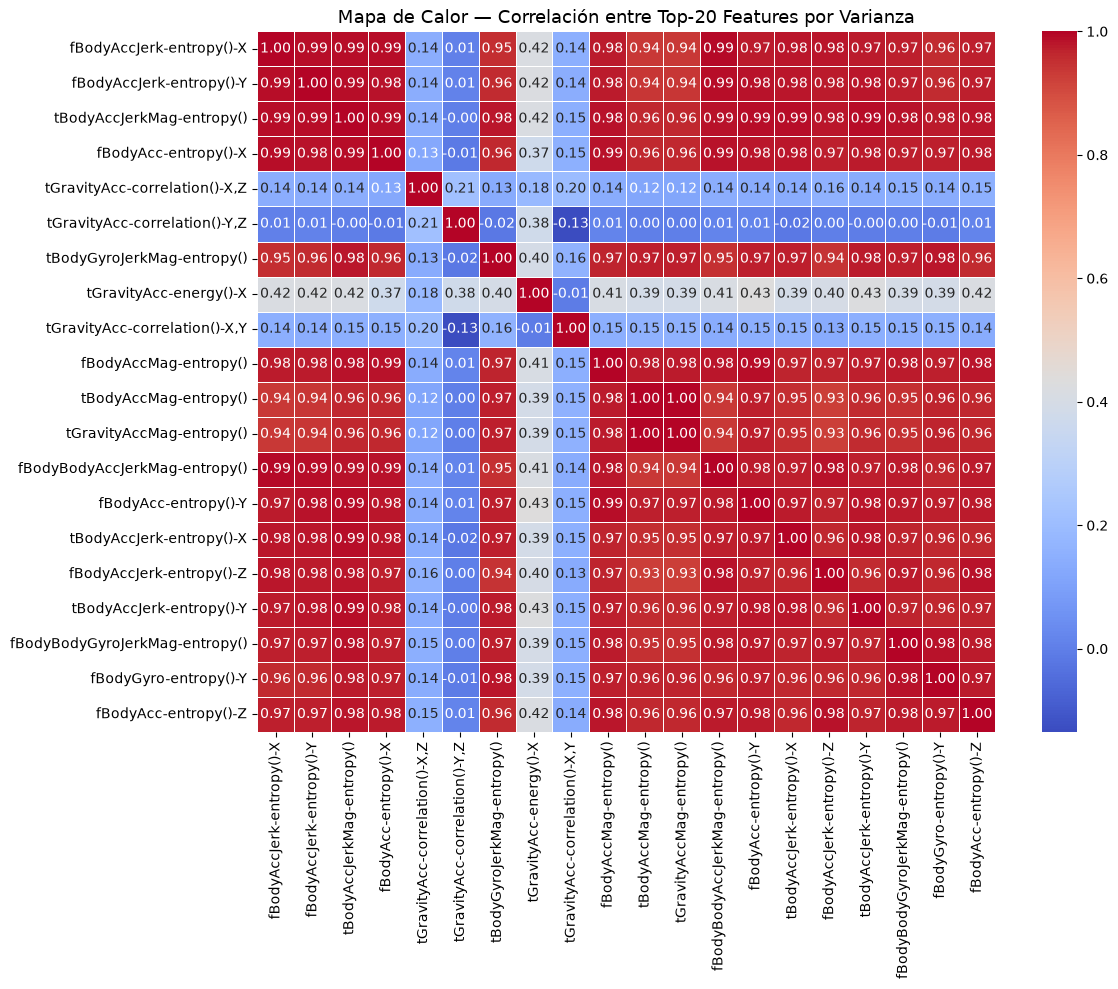

In [51]:
# TODO 12: Seleccionar las 20 features con mayor varianza
top_var_features = X_train.var().nlargest(20).index.tolist()

# TODO 13: Calcular y graficar el heatmap de correlación
corr_matrix = X_train[top_var_features].corr()

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    ax=ax
)
ax.set_title('Mapa de Calor — Correlación entre Top-20 Features por Varianza', fontsize=13)
plt.tight_layout()
plt.show()

### 📝 Análisis en Markdown para Heatmap

**Implicaciones de la alta correlación:** En el mapa de calor obtenido, se observa que la inmensa mayoría de las 20 características con mayor varianza (principalmente métricas de entropía como `fBodyAccJerk-entropy()`, `fBodyAcc-entropy()` y variables de magnitud `Mag`) presentan una correlación lineal extremadamente alta entre sí, superando en casi todos los casos coeficientes de 0.95. Las únicas excepciones que escapan a esta redundancia son las métricas de correlación y energía cruzada de la gravedad (como `tGravityAcc-correlation()` y `tGravityAcc-energy()`). 

Una alta correlación positiva o negativa entre variables indica la presencia de **multicolinealidad** (redundancia severa de información). Para modelos lineales como la Regresión Logística, esto puede desestabilizar la estimación de los coeficientes óptimos y perjudicar la convergencia. Para algoritmos basados en distancias como K-Nearest Neighbors (KNN), puede sobredimensionar la importancia de un eje sensor redundante. En contraste, los modelos basados en árboles de decisión o ensamblados (Random Forest) suelen lidiar bastante bien con esto, aunque la importancia individual de las features tienda a dispersarse.

### 4.3 Reducción de dimensionalidad — PCA

### Código para los TODOs 14 y 15 (PCA)

In [52]:
# TODO 14: Aplicar PCA para reducir a 2 dimensiones
pca = PCA(n_components=2, random_state=RANDOM_STATE)

# Ajustar y transformar X_train
X_pca = pca.fit_transform(X_train)

df_pca = pd.DataFrame(X_pca, columns=['PC1', 'PC2'])
df_pca['Activity'] = y_train_labels.values

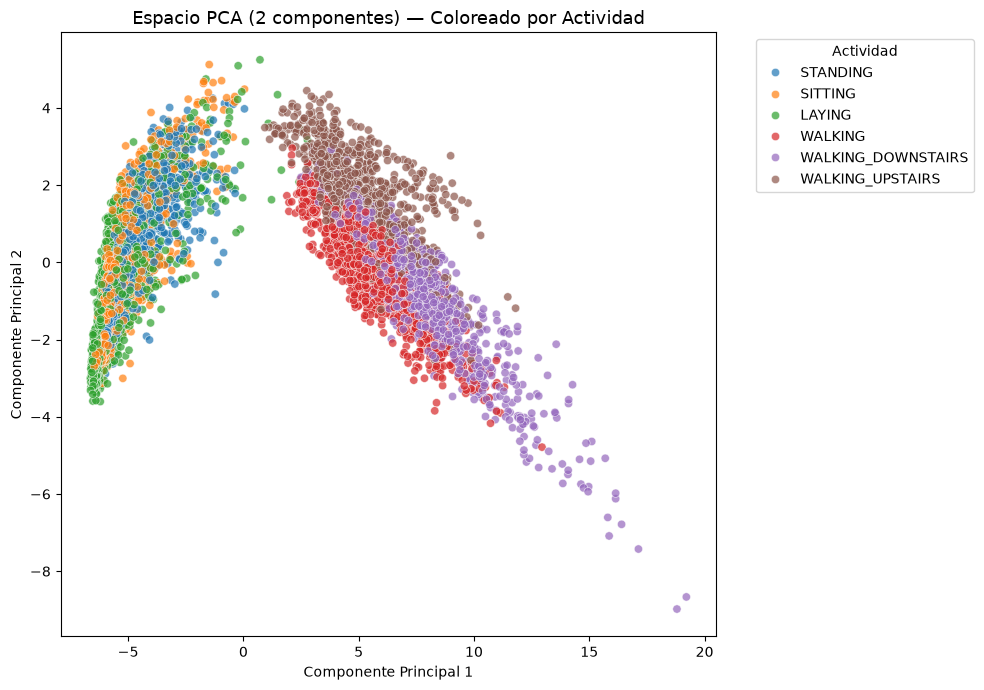

Varianza explicada PC1: 0.626
Varianza explicada PC2: 0.049
Varianza acumulada total: 0.675


In [53]:
# TODO 15: Graficar espacio PCA coloreando por clase de actividad
fig, ax = plt.subplots(figsize=(10, 7))

sns.scatterplot(x='PC1', y='PC2', hue='Activity', data=df_pca, palette='tab10', alpha=0.7, ax=ax)

ax.set_title('Espacio PCA (2 componentes) — Coloreado por Actividad', fontsize=13)
ax.set_xlabel('Componente Principal 1')
ax.set_ylabel('Componente Principal 2')
ax.legend(title='Actividad', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Varianza explicada
print(f'Varianza explicada PC1: {pca.explained_variance_ratio_[0]:.3f}')
print(f'Varianza explicada PC2: {pca.explained_variance_ratio_[1]:.3f}')
print(f'Varianza acumulada total: {pca.explained_variance_ratio_.sum():.3f}')

### 📝 Análisis en Markdown para PCA

**Interpretación del espacio PCA:** 
La proyección en 2 dimensiones principales ratifica visualmente la existencia de los dos grandes patrones de movimiento en el dataset. A la **izquierda** del gráfico (valores negativos de la Componente Principal 1), las actividades **estáticas** (STANDING, SITTING, LAYING) se agrupan firmemente. A la **derecha** (valores de la Componente Principal 1 superiores a cero), las actividades **dinámicas** (los tres tipos de caminatas) forman otro bloque claramente identificable.

**¿Cuáles se solapan y qué sugiere?:** Existe un solapamiento muy evidente entre las clases **SITTING** (sentado) y **STANDING** (de pie). Físicamente tiene sentido, ya que el torso mantiene una verticalidad similar en reposo en ambos escenarios. Esto nos sugiere que, aunque el problema tiene una base de separabilidad lineal fuerte para discriminar el movimiento elemental, necesitaremos modelos con fronteras de decisión más complejas o hiperplanos no lineales (como un Support Vector Machine con Kernel RBF) para destrabar con precisión la confusión entre estar sentado o de pie.

### 4.4 Visualización adicional (libre)

Para cumplir con la quinta visualización obligatoria de la rúbrica, graficaremos la distribución de densidad estimada (KDE) de la magnitud del promedio de aceleración del cuerpo. Esto ilustra de manera elegante los niveles de energía cinética por actividad.

### Código para el TODO 16 (Visualización adicional libre)

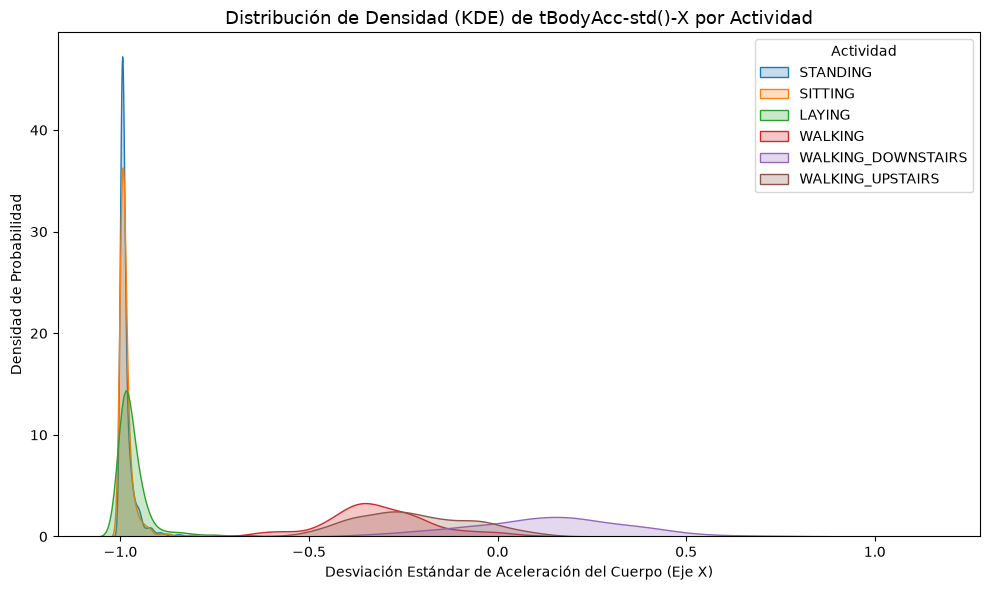

In [54]:
# TODO 16: Visualización adicional a elección del grupo (Gráfico KDE de Energía)
# Usaremos una variable clásica de energía o magnitud si está disponible, o una desviación estándar del movimiento temporal.
feat_adicional = 'tBodyAcc-std()-X'

fig, ax = plt.subplots(figsize=(10, 6))
for activity in y_train_labels.unique():
    subset = X_train[y_train_labels == activity]
    sns.kdeplot(subset[feat_adicional], label=activity, shade=True, alpha=0.25, ax=ax)

ax.set_title(f'Distribución de Densidad (KDE) de {feat_adicional} por Actividad', fontsize=13)
ax.set_xlabel('Desviación Estándar de Aceleración del Cuerpo (Eje X)')
ax.set_ylabel('Densidad de Probabilidad')
ax.legend(title='Actividad')
plt.tight_layout()
plt.show()

### 📝 Análisis en Markdown para la Visualización Adicional

**Análisis e interpretación:** Este gráfico de densidad (KDE) demuestra empíricamente que la variabilidad de la aceleración del cuerpo (`tBodyAcc-std()-X`) es un indicador directo de la intensidad física de la actividad. Las actividades **estáticas** se concentran agudamente en valores extremadamente bajos (cercanos a -1), reflejando ausencia de aceleración propia del movimiento. En cambio, las **caminatas** se desplazan hacia la derecha, destacando **WALKING_DOWNSTAIRS** (bajar escaleras) como una de las actividades con mayor dispersión de impactos cinéticos debido a la fuerza de gravedad descendente involucrada.

---
## 5. Preparación Final de Datos y Resumen

### Código para los TODOs 17 y 18

In [55]:
# TODO 17: Confirmar que el split train/test viene predefinido (NO crear uno propio)
print('Estructura de splits verificada.')
print(f'Muestras de entrenamiento asignadas de forma fija: {X_train.shape[0]}')
print(f'Muestras de prueba asignadas de forma fija:        {X_test.shape[0]}')

Estructura de splits verificada.
Muestras de entrenamiento asignadas de forma fija: 7352
Muestras de prueba asignadas de forma fija:        2947


### 📝 Análisis en Markdown sobre la importancia del Split Fijo

**¿Por qué es importante respetar el split original?:** En el dataset UCI HAR, las mediciones provienen de ventanas de tiempo continuas ejecutadas secuencialmente por 30 sujetos distintos. Los creadores separaron los datos **a nivel de sujeto** (por ejemplo, ciertos voluntarios van exclusivamente a entrenamiento y otros a prueba).

Si hiciéramos un split aleatorio tradicional (`train_test_split` mezclando todas las filas), estaríamos cometiendo **Data Leakage** (fuga de datos). Ventanas temporales consecutivas y altamente correlacionadas del mismo sujeto quedarían repartidas simultáneamente en ambos conjuntos. El modelo memorizaría los patrones particulares de movimiento de esos usuarios específicos, dándonos una precisión falsamente optimista en el set de prueba que caería estrepitosamente al intentar generalizar el sistema con personas completamente nuevas en el mundo real.

In [56]:
# TODO 18: Exportar variables limpias para la Fase 2
# (Confirmar estados finales e imprimir celda de validación requerida)
print('=' * 50)
print('RESUMEN FINAL FASE 1')
print('=' * 50)
print(f'Dimensiones finales X_train: {X_train.shape}')
print(f'Dimensiones finales X_test:  {X_test.shape}')
print(f'Número de clases:            {len(ACTIVITY_LABELS)}')
print(f'Nombres de clases:           {list(ACTIVITY_LABELS.values())}')
print(f'Valores faltantes totales:   {X_train.isnull().sum().sum() + X_test.isnull().sum().sum()}')
print(f'Duplicados en train:         {X_train.duplicated().sum()}')
print('=' * 50)

RESUMEN FINAL FASE 1
Dimensiones finales X_train: (7352, 561)
Dimensiones finales X_test:  (2947, 561)
Número de clases:            6
Nombres de clases:           ['WALKING', 'WALKING_UPSTAIRS', 'WALKING_DOWNSTAIRS', 'SITTING', 'STANDING', 'LAYING']
Valores faltantes totales:   0
Duplicados en train:         0
